<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/RNN_AirPassengers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


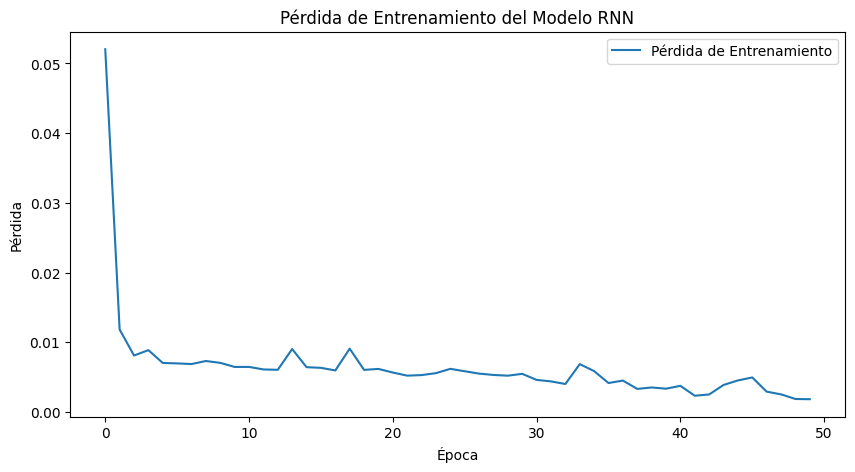

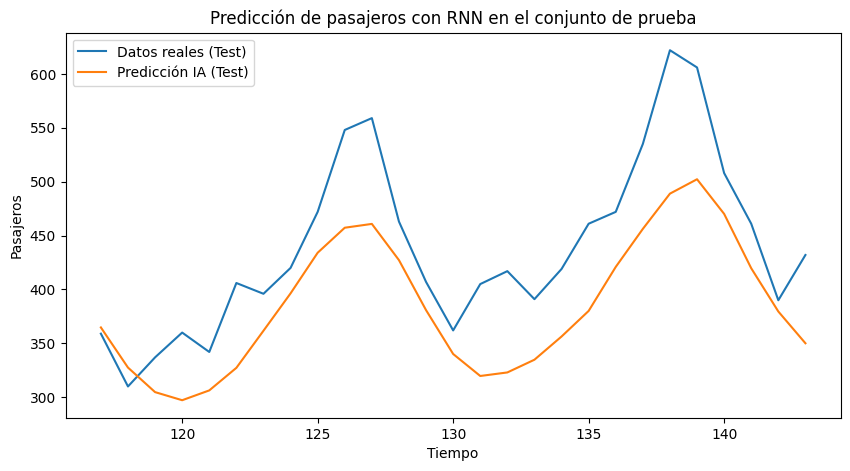

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Dataset AirPassengers
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

# Usar columna de pasajeros
data = df['Passengers'].values.reshape(-1,1)

# Normalizar
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

# Crear secuencias
x = []
y = []
window = 12
for i in range(window, len(data_scaled)):
  x.append(data_scaled[i-window:i, 0])
  y.append(data_scaled[i, 0])

x = np.array(x)
y = np.array(y)

# Ajustar forma para LSTM
x = np.reshape(x, (x.shape[0], x.shape[1], 1))

# Dividir los datos en entrenamiento y prueba (e.g., 80% entrenamiento, 20% prueba)
split = int(len(x) * 0.8)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

# Crear modelo
model = Sequential()
# Aumentar las unidades LSTM y el número de épocas para intentar mejorar el rendimiento
model.add(LSTM(100, input_shape=(x_train.shape[1],1))) # Increased LSTM units from 50 to 100
model.add(Dense(1))

# Compilar
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar
history = model.fit(x_train, y_train, epochs=50, batch_size=8, verbose=0) # Increased epochs from 30 to 50

# Predicciones en el conjunto de prueba
predictions_test_scaled = model.predict(x_test)

# Regresar valores originales
predictions_test = scaler.inverse_transform(predictions_test_scaled)
real_test = scaler.inverse_transform(y_test.reshape(-1,1))

# Graficar la pérdida del entrenamiento
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.title('Pérdida de Entrenamiento del Modelo RNN')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

# Graficar predicciones vs datos reales para el conjunto de prueba
plt.figure(figsize=(10,5))

# Ajustar el índice para la gráfica
original_indices = np.arange(len(data_scaled))
plot_indices = original_indices[split + window:]

plt.plot(plot_indices, real_test, label="Datos reales (Test)")
plt.plot(plot_indices, predictions_test, label="Predicción IA (Test)")
plt.title("Predicción de pasajeros con RNN en el conjunto de prueba")
plt.xlabel("Tiempo")
plt.ylabel("Pasajeros")
plt.legend()
plt.show()

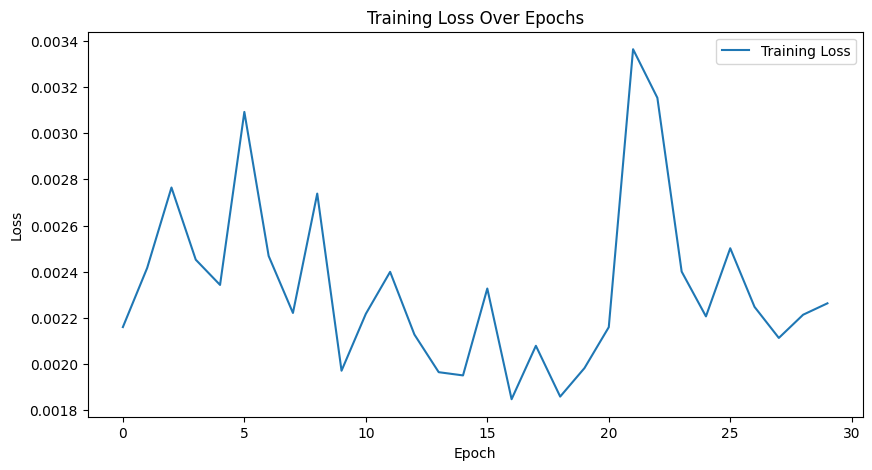

In [11]:
history = model.fit(x, y, epochs=30, batch_size=8, verbose=0) # Re-run fit to capture history

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()